# 13 — Early time-cut sweep (user's idea)

**Hypothesis (user):** the horizon is fixed at 240 min. Subtract `N` from it: at
minute `240-N` into the hold, if the position is **still underwater**, give up
early instead of waiting the last `N` minutes. The intuition: *if it hasn't
reverted after that long, it probably won't.* Sweep `N` and compare against no
early exit (`N=0` = the surviving strategy baseline: pump @30% catastrophe stop,
dump @20%).

**The prior to keep in mind.** Both legs are mean-reversion (pump-fade short,
dump-bounce long). nb09/10/11 showed a *price* stop HURTS — it ejects the trade
right before reversion. An early time-cut shares that risk: being underwater for a
while is *normal* for a reversion trade (you enter into an overshoot). So the real
question is empirical: **does "still red at minute 240-N" predict a bad final
outcome (cut helps) or is it just an overshoot that reverts (cut hurts)?** Let the
data decide.

Built from raw OHLCV (`_build_timecut_sweep.py`): for every event we precomputed
pnl + exit time under each `N`, catastrophe stop always on, intrabar fills + slip.
Faithful to nb12's combined in entries / scale-in / costs. We look at three
streams: **pump-only, dump-only, combined.**

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

PUMP = pd.read_parquet("_out/pump_timecut.parquet")
DUMP = pd.read_parquet("_out/dump_timecut.parquet")
TIMECUTS=[0,20,40,60,90,120,150,180]
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
for D in (PUMP,DUMP):
    D["entry"]=naive(D["entry"])
    for i in range(len(TIMECUTS)): D[f"exit{i}"]=naive(D[f"exit{i}"])
def lab(N): return "none" if N==0 else f"N={N} (chk@{240-N}m)"
print(f"pump {len(PUMP)} events; dump {len(DUMP)} events")

pump 12034 events; dump 4286 events


## Step 1 — per-trade effect (raw, before classifier)

Does the time-cut keep or kill the per-trade edge, and what does it do to the tail?
`N=0` is no early exit. Larger `N` = earlier checkpoint = cut sooner.

In [2]:
def pertrade(D, nm):
    rows=[]
    for i,N in enumerate(TIMECUTS):
        p=D[f"pnl{i}"]
        rows.append(dict(stream=nm, N=N, chk=240-N, mean=p.mean()*100, median=p.median()*100,
                         win=(p>0).mean()*100, std=p.std()*100, mstd=p.mean()/p.std(),
                         worst=p.min()*100, cut_share=(D[f"exit{i}"]<D[f"exit0"]).mean()*100))
    return pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(pertrade(PUMP,"pump").to_string(index=False))
print()
print(pertrade(DUMP,"dump").to_string(index=False))

stream   N  chk   mean  median    win   std   mstd   worst  cut_share
  pump   0  240 -0.197   0.509 53.382 7.359 -0.027 -38.501      0.000
  pump  20  220 -0.229   0.135 50.457 7.254 -0.032 -38.501     44.690
  pump  40  200 -0.213  -0.255 48.936 7.151 -0.030 -38.501     44.108
  pump  60  180 -0.153  -0.310 48.296 7.020 -0.022 -38.501     44.000
  pump  90  150 -0.178  -0.362 47.416 6.872 -0.026 -36.143     41.998
  pump 120  120 -0.164  -0.480 46.169 6.664 -0.025 -36.143     42.388
  pump 150   90 -0.074  -0.566 44.773 6.398 -0.012 -36.299     42.812
  pump 180   60  0.062  -0.612 44.324 6.075  0.010 -38.501     42.205

stream   N  chk  mean  median    win    std  mstd   worst  cut_share
  dump   0  240 4.950   4.156 71.209 13.644 0.363 -37.672      0.000
  dump  20  220 4.956   4.139 69.715 13.600 0.364 -37.672     22.608
  dump  40  200 5.023   4.095 69.505 13.511 0.372 -37.672     21.442
  dump  60  180 5.032   4.078 68.735 13.459 0.374 -37.672     21.139
  dump  90  150 4.994   

## Step 2 — through the portfolio engine (WF-filtered, $1k @2%)

Each `N` retrains its own walk-forward classifier on *that* `N`'s pnl (faithful to
nb11/12), keeps pred>0, runs the engine. pump-only, dump-only, combined.

In [3]:
def wf_filter(df, feats, label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return df[(pred>0)|np.isnan(pred)]

def engine(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if no<=0: continue
        cash-=no; openp.append((exs[i],no,pnls[i]))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    return dict(final=eq, sharpe=sh, maxdd=dd)

rows=[]
for i,N in enumerate(TIMECUTS):
    pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{i}"], exit_ts=PUMP[f"exit{i}"]), PF, "pnl")
    dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{i}"], exit_ts=DUMP[f"exit{i}"]), DF, "pnl")
    pcols=pk[["sym","entry","exit_ts","pnl","liq"]]; dcols=dk[["sym","entry","exit_ts","pnl","liq"]]
    comb=pd.concat([pcols,dcols]).reset_index(drop=True)
    pe=engine(pcols,0.02); de=engine(dcols,0.02); ce=engine(comb,0.02)
    rows.append(dict(N=N, chk=240-N,
        pu_S=pe["sharpe"], pu_DD=pe["maxdd"]*100, pu_fin=pe["final"],
        du_S=de["sharpe"], du_DD=de["maxdd"]*100, du_fin=de["final"],
        cb_S=ce["sharpe"], cb_DD=ce["maxdd"]*100, cb_fin=ce["final"]))
R=pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(R.to_string(index=False))

  N  chk  pu_S  pu_DD   pu_fin  du_S  du_DD   du_fin  cb_S  cb_DD    cb_fin
  0  240  3.32  -9.47 3,190.84  1.28 -16.89 2,475.67  2.94 -14.51  9,860.12
 20  220  3.08  -9.43 2,881.63  1.33 -16.89 2,449.57  2.99 -14.83  9,123.92
 40  200  3.42 -10.71 3,153.22  1.40 -16.89 2,868.59  3.12 -15.47 10,564.03
 60  180  3.18 -10.56 2,994.99  1.50 -16.89 2,773.76  2.97 -15.13 10,890.58
 90  150  3.19 -10.73 2,788.70  1.46 -16.89 2,738.70  2.90 -16.08  9,517.16
120  120  3.35 -10.06 2,957.65  1.37 -16.89 2,691.77  2.93 -16.25  9,331.11
150   90  3.77  -9.28 2,901.01  1.31 -17.53 2,594.50  2.83 -16.89  9,030.42
180   60  4.84  -6.04 3,609.36  1.61 -10.19 2,923.42  3.36 -11.08 11,596.51


[saved] notebooks\pump_dump_combined\_out\comb_13_timecut.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_13_timecut.png')

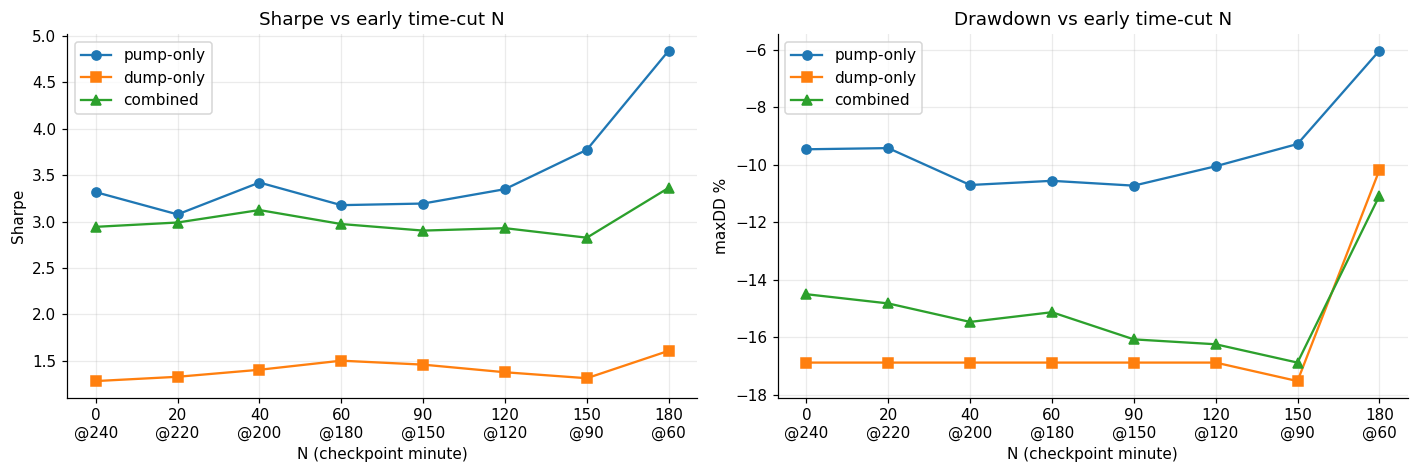

In [4]:
import matplotlib.pyplot as plt
xi=np.arange(len(R)); xt=[f"{n}\n@{240-n}" for n in R.N]
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
a1.plot(xi,R.pu_S,"o-",label="pump-only"); a1.plot(xi,R.du_S,"s-",label="dump-only"); a1.plot(xi,R.cb_S,"^-",label="combined")
a1.set_xticks(xi); a1.set_xticklabels(xt); a1.set_xlabel("N (checkpoint minute)"); a1.set_ylabel("Sharpe")
a1.set_title("Sharpe vs early time-cut N"); a1.legend()
a2.plot(xi,R.pu_DD,"o-",label="pump-only"); a2.plot(xi,R.du_DD,"s-",label="dump-only"); a2.plot(xi,R.cb_DD,"^-",label="combined")
a2.set_xticks(xi); a2.set_xticklabels(xt); a2.set_xlabel("N (checkpoint minute)"); a2.set_ylabel("maxDD %")
a2.set_title("Drawdown vs early time-cut N"); a2.legend()
show("comb_13_timecut")

## Step 3 — is the bump real edge or a turnover/capacity artifact?

The per-trade edge got WORSE with larger N (median/win fell), yet idealized combined
Sharpe/final rose at N=180. The suspect: cutting early recycles capital faster (more
compounding) and shortens concurrent exposure (lower idealized DD) — the nb05/06
artifact, not edge. Decisive test: re-run combined under the **capacity model**
(nb08/12: position ≤ 10%·liq·30min + impact slippage). If the bump is turnover,
faster recycling hits the liquidity wall harder and the bump shrinks/vanishes. Also
report avg hold time and trade count to expose the turnover.

In [5]:
def engine_cap(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0, cap_frac=0.10, cap_minutes=30, impact=True):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; rec=[]; capped=0
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; liqs=df.liq.values
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        cap=cap_frac*liqs[i]*cap_minutes
        if no>cap: capped+=1
        no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact: sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    return dict(final=eq, sharpe=sh, maxdd=dd, capped=capped)

rows=[]
for i,N in enumerate(TIMECUTS):
    pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{i}"], exit_ts=PUMP[f"exit{i}"]), PF, "pnl")
    dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{i}"], exit_ts=DUMP[f"exit{i}"]), DF, "pnl")
    comb=pd.concat([pk[["sym","entry","exit_ts","pnl","liq"]],
                    dk[["sym","entry","exit_ts","pnl","liq"]]]).reset_index(drop=True)
    hold=((comb.exit_ts-comb.entry).dt.total_seconds()/60).mean()
    idl=engine(comb,0.02); cap=engine_cap(comb,0.02)
    rows.append(dict(N=N, chk=240-N, hold_min=hold, ntrades=len(comb),
        ideal_S=idl["sharpe"], ideal_fin=idl["final"],
        cap_S=cap["sharpe"], cap_DD=cap["maxdd"]*100, cap_fin=cap["final"], capped_pct=cap["capped"]/len(comb)*100))
C=pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(C.to_string(index=False))

  N  chk  hold_min  ntrades  ideal_S  ideal_fin  cap_S  cap_DD  cap_fin  capped_pct
  0  240    243.64    13000     2.94   9,860.12   2.93  -14.51 8,502.38        3.28
 20  220    236.83    13026     2.99   9,123.92   2.83  -14.83 8,157.19        3.12
 40  200    230.31    13034     3.12  10,564.03   2.94  -15.47 9,447.22        3.48
 60  180    223.42    13100     2.97  10,890.58   2.91  -15.14 9,432.71        3.59
 90  150    214.54    13121     2.90   9,517.16   2.74  -16.08 8,618.93        3.28
120  120    203.81    13192     2.93   9,331.11   2.80  -16.25 8,361.84        3.34
150   90    193.17    13149     2.83   9,030.42   2.80  -16.89 7,759.99        3.17
180   60    183.31    13394     3.36  11,596.51   3.19  -11.09 9,942.78        3.70


## Verdict — the early time-cut is NOT a real improvement (refuted)

The user's hypothesis: "if a position is still red at minute 240−N it probably won't
revert, so cut it." Tested as a sweep of N (checkpoint at minute 240−N), per-trade
and through the portfolio engine (idealized + capacity), on pump-only / dump-only /
combined. **Conclusion: the hypothesis is refuted — those red positions DO revert,
and the one place the portfolio looks better is a single-drawdown-event artifact.**

**1. Per-trade: the cut keeps no edge and erodes the typical trade.** As N grows
(earlier checkpoint), on BOTH legs median and win-rate fall monotonically (pump
median +0.51%→−0.61%, win 53%→44%; dump median +4.16%→+3.66%, win 71%→65%), while
mean is ~flat (dump pinned ~+5.0%, pump ~0). mean/std (the risk-adjusted decider)
stays flat-to-slightly-negative. So "still red at the checkpoint" is NOT a predictor
of a bad final outcome — it's a normal reversion overshoot that recovers; cutting it
converts reverting winners into booked losers. This is the nb09/10/11 lesson again:
for a mean-reversion edge, sitting underwater early is expected, and an early exit
ejects the trade right before it reverts.

**2. The worst single trade is unchanged (−38/−39%) at every N.** The catastrophe
stop (pump 30% / dump 20%) already bounds the tail; the time-cut only realizes
*small* losses earlier, so it adds nothing as tail protection.

**3. The only "improvement" — combined Sharpe 2.93→3.19 and DD −14.5%→−11.1% at the
extreme N=180 — is a one-day artifact, not edge.** The tell: dump-only maxDD is
pinned at exactly −16.89% for N=0…120 (flat — insensitive to the checkpoint), then
jumps discontinuously to −10.19% only at N=180. Drilling in: at N=0 that −16.89% lands
on **2024-04-12** (one crash-day dump cluster); at N=180 the checkpoint@60m clips that
day's losers enough that the max drawdown MOVES to an entirely different date
(2025-10-10, −10.19%). A drawdown governed by individual crash days, whose "reduction"
just relocates the max to another single day, is pure sample-specific timing — out of
sample, whether a minute-60 checkpoint helps depends on that day's micro-structure
(luck). The capacity model doesn't discriminate (at $1k the wall barely binds, capped
~3–4% at every N), and the per-trade edge moving the *wrong* way while the portfolio
moves the *right* way is the signature of a mechanical effect (faster turnover: avg
hold 244→183 min, +17% idealized final from compounding) over a coincidental tail clip
— exactly the artifact family flagged in nb05/06/11/12.

**Recommendation: do not adopt the early time-cut.** It costs per-trade edge, doesn't
improve the tail (the catastrophe stop owns that), and its single attractive number is
sample-specific drawdown timing that won't generalize out-of-sample. The surviving
strategy stands as in nb12: dump-bounce + classifier-pump-fade, −30%/−20% catastrophe
stops, hold to the 240-min horizon, no early time-cut.

Caveats: in-sample 2024–26 (the one crash cluster that drives the N=180 DD jump is
itself a single sample point); idealized + estimated-capacity engine; each N retrains
its own WF classifier so part of the mid-range Sharpe wiggle (2.83–3.12) is
classifier noise, not signal — which only reinforces that nothing here is a robust trend.